### Task 1: Exploratory Data Analysis (EDA):

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [89]:
df = pd.read_csv("wine.csv")

In [90]:
df.shape

(178, 14)

In [91]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [93]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [94]:
#checking duplicates
df.duplicated().sum()

0

In [95]:
# No duplicates are presented in data

In [96]:
#checking missing values
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [97]:
# no missing values present in data

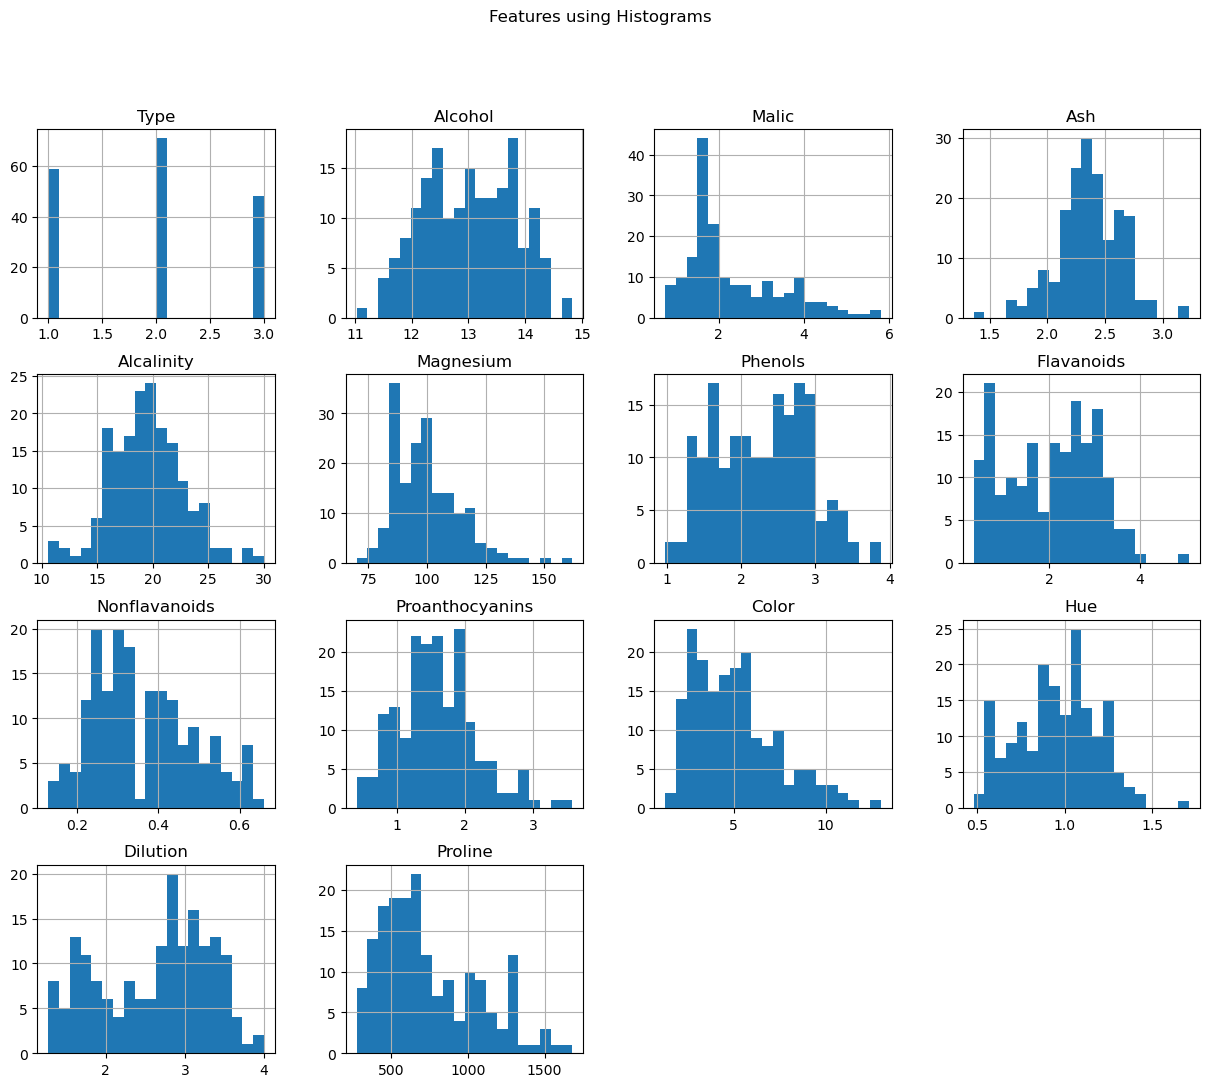

In [98]:
# histogram
df.hist(figsize=(15,12), bins=20)
plt.suptitle("Features using Histograms")
plt.show()

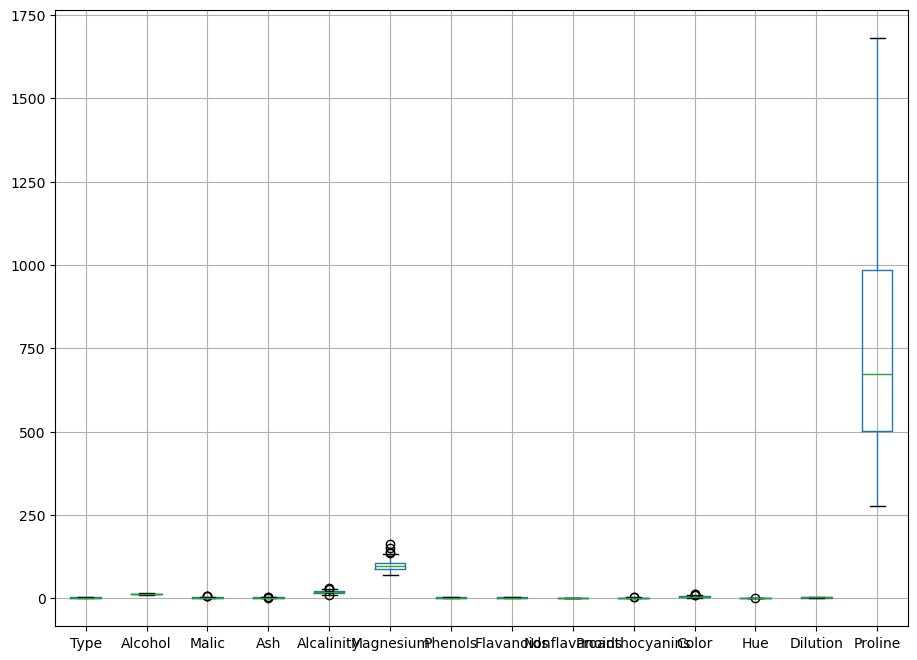

In [99]:
#checking outliers by using boxplot
plt.figure(figsize=(11,8))
df.boxplot()
plt.show()

In [100]:
#outlier capping 
def outlier_capping(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0.75)
    iqr=q3-q1
    lower_extreme=q1-1.5*iqr
    high_extreme=q3+1.5*iqr
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else high_extreme if x>high_extreme else x)
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

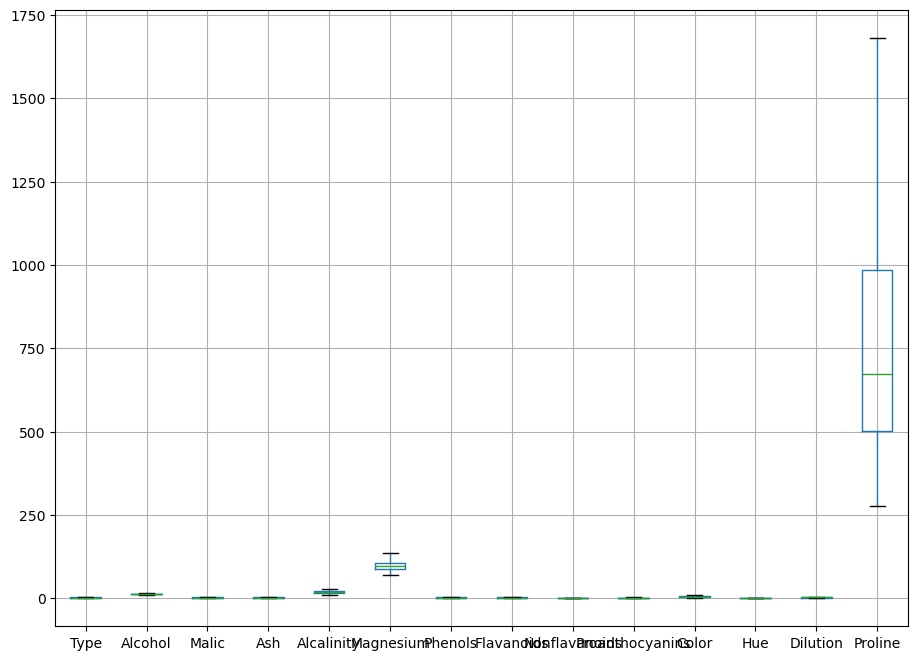

In [101]:
#checking outliers by using boxplot after outlier capping
plt.figure(figsize=(11,8))
df.boxplot()
plt.show()

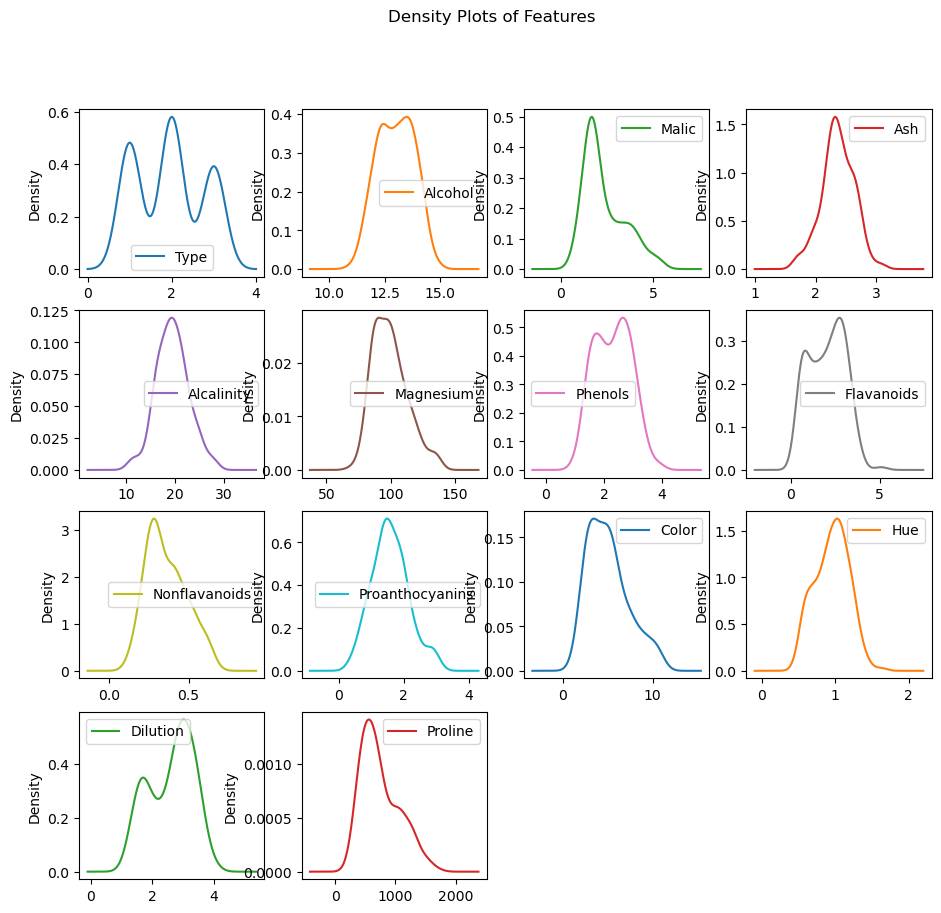

In [102]:
#density plot 
df.plot(kind='density', subplots=True,layout=(4,4),
        figsize=(11,10), sharex=False)
plt.suptitle("Density Plots of Features")
plt.show()

In [103]:
# Correlation Analysis
df.corr()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.440422,-0.047680,0.525608,-0.224264,-0.719163,-0.847498,0.489109,-0.512528,0.260260,-0.621549,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094756,0.220174,-0.312191,0.302173,0.289101,0.236815,-0.155929,0.153171,0.549107,-0.067156,0.072343,0.643720
Malic,0.440422,0.094756,1.000000,0.166614,0.295882,-0.039329,-0.339050,-0.414875,0.294203,-0.234575,0.264897,-0.566409,-0.372582,-0.191173
Ash,-0.047680,0.220174,0.166614,1.000000,0.427713,0.322510,0.124436,0.097562,0.183666,0.006080,0.256799,-0.075904,-0.011214,0.229676
Alcalinity,0.525608,-0.312191,0.295882,0.427713,1.000000,-0.098030,-0.333046,-0.363405,0.369276,-0.208794,0.009748,-0.286664,-0.287032,-0.448700
Magnesium,-0.224264,0.302173,-0.039329,0.322510,-0.098030,1.000000,0.227035,0.209431,-0.255674,0.201428,0.240505,0.040007,0.064019,0.411557
Phenols,-0.719163,0.289101,-0.339050,0.124436,-0.333046,0.227035,1.000000,0.864564,-0.449935,0.618771,-0.062101,0.435952,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.414875,0.097562,-0.363405,0.209431,0.864564,1.000000,-0.537900,0.665384,-0.169807,0.546718,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.294203,0.183666,0.369276,-0.255674,-0.449935,-0.537900,1.000000,-0.368455,0.131596,-0.266995,-0.503270,-0.311385
Proanthocyanins,-0.512528,0.153171,-0.234575,0.006080,-0.208794,0.201428,0.618771,0.665384,-0.368455,1.000000,-0.032693,0.306289,0.530565,0.340562


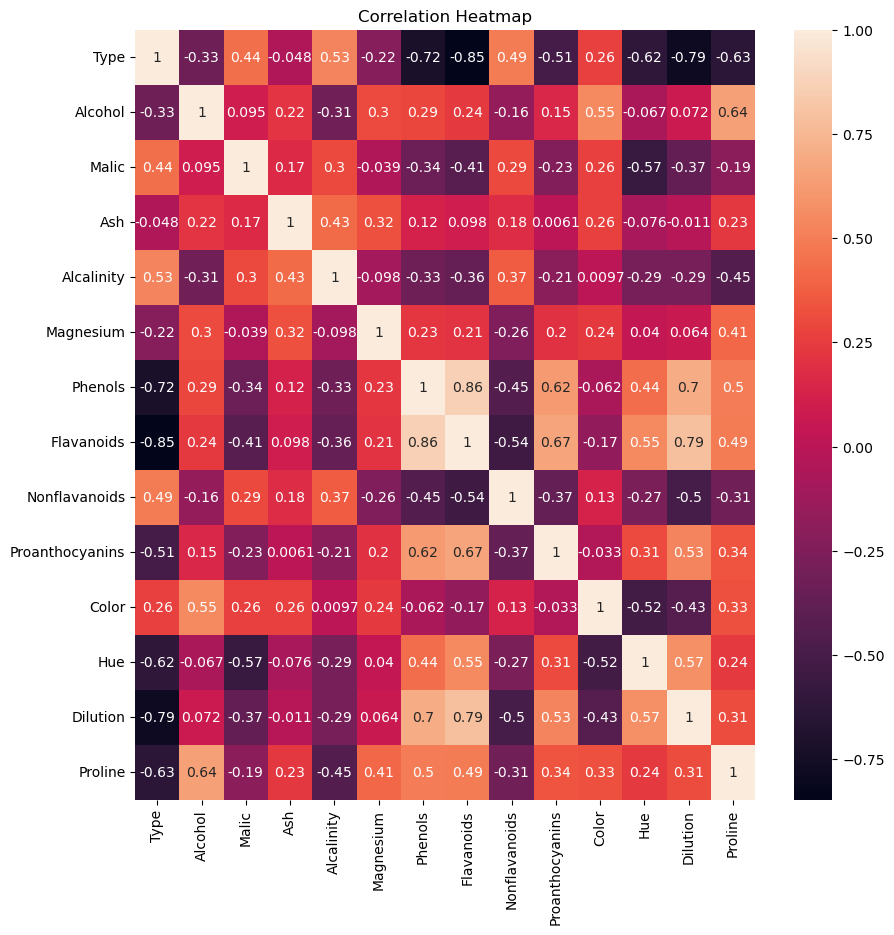

In [104]:
# Heatmap
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Task 2: Dimensionality Reduction with PCA:

In [105]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [106]:
features = df.drop('Type',axis=1)
target = df[['Type']]
np.unique(target)

array([1, 2, 3], dtype=int64)

In [107]:
# Standardization
scaler = StandardScaler()
features_scaled= scaler.fit_transform(features)
features_scaled= pd.DataFrame(features_scaled,columns=features.columns)
features_scaled

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.709072,0.316696,0.311700,-0.335152,-0.985614,-1.424900,1.274310,-0.945173,1.180674,-1.399735,-1.231206,-0.021952
174,0.493343,1.439792,0.430781,1.074241,0.188156,-0.793334,-1.284344,0.549108,-0.316336,1.003253,-1.134784,-1.485445,0.009893
175,0.332758,1.777051,-0.405838,0.159191,1.533804,-1.129824,-1.344582,0.549108,-0.424137,2.289557,-1.620528,-1.485445,0.280575
176,0.209232,0.236596,0.012471,0.159191,1.533804,-1.033684,-1.354622,1.354888,-0.226502,1.890359,-1.576370,-1.400699,0.296498


In [108]:
pca = PCA(n_components=2)
pca_data=pca.fit_transform(features_scaled)

In [109]:
# Convert to DataFrame with column names
pca_data = pd.DataFrame(pca_data,columns=['PC1', 'PC2'])
pca_data

,PC1,PC2
0,3.358147,1.520222
1,2.229215,-0.333261
2,2.540057,1.036953
3,3.781124,2.782566
4,1.016872,0.955225
...,...,...
173,-3.311751,2.173369
174,-2.612425,1.797712
175,-2.671169,2.865301
176,-2.371603,2.393808


In [110]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")
print(explained_variance)


Explained Variance Ratio:
[0.36475803 0.19609775]


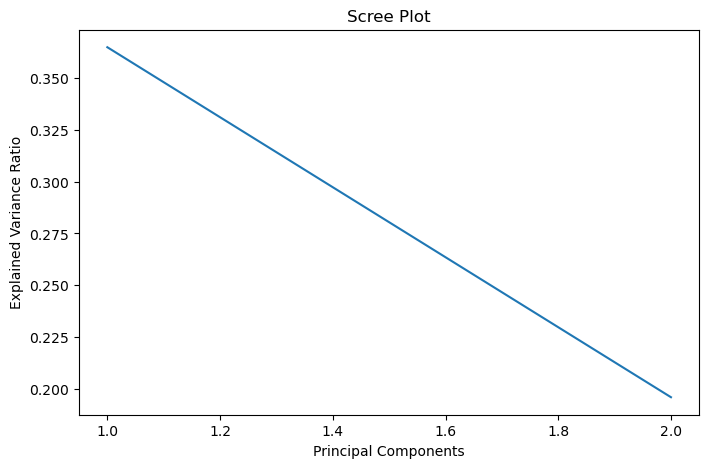

In [111]:
# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1),explained_variance)
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

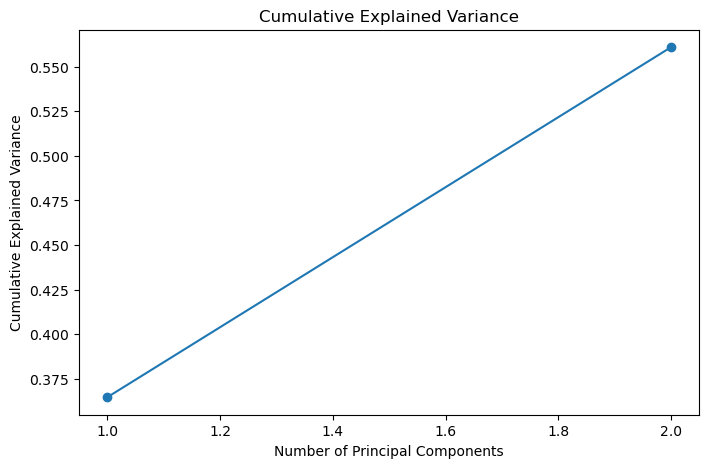

In [112]:
# Cumulative Explained Variance
plt.figure(figsize=(8,5))
plt.plot(range(1, len(np.cumsum(explained_variance))+1),
         np.cumsum(explained_variance),
         marker='o')

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.show()



### Task 3: Clustering with Original Data:

In [113]:
from sklearn.cluster import KMeans

In [114]:
kmeans = KMeans(n_clusters=3,random_state=42)

In [115]:
clusters = kmeans.fit_predict(features_scaled)

In [116]:
features_scaled['cluster'] = clusters
features_scaled

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,cluster
0,1.518613,-0.565534,0.240640,-1.182882,2.057111,0.808997,1.034819,-0.659563,1.264740,0.266954,0.366610,1.847920,1.013009,2
1,0.246290,-0.501728,-0.862176,-2.524956,0.038639,0.568648,0.733629,-0.820719,-0.549904,-0.291923,0.410768,1.113449,0.965242,2
2,0.196879,0.026948,1.153315,-0.267832,0.113397,0.808997,1.215533,-0.498407,2.199012,0.284696,0.322451,0.788587,1.395148,2
3,1.691550,-0.346771,0.506837,-0.816862,1.010496,2.491446,1.466525,-0.981875,1.067105,1.225029,-0.428246,1.184071,2.334574,2
4,0.295700,0.236596,1.913878,0.464208,1.384287,0.808997,0.663351,0.226796,0.420301,-0.318536,0.366610,0.449601,-0.037874,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.709072,0.316696,0.311700,-0.335152,-0.985614,-1.424900,1.274310,-0.945173,1.180674,-1.399735,-1.231206,-0.021952,1
174,0.493343,1.439792,0.430781,1.074241,0.188156,-0.793334,-1.284344,0.549108,-0.316336,1.003253,-1.134784,-1.485445,0.009893,1
175,0.332758,1.777051,-0.405838,0.159191,1.533804,-1.129824,-1.344582,0.549108,-0.424137,2.289557,-1.620528,-1.485445,0.280575,1
176,0.209232,0.236596,0.012471,0.159191,1.533804,-1.033684,-1.354622,1.354888,-0.226502,1.890359,-1.576370,-1.400699,0.296498,1


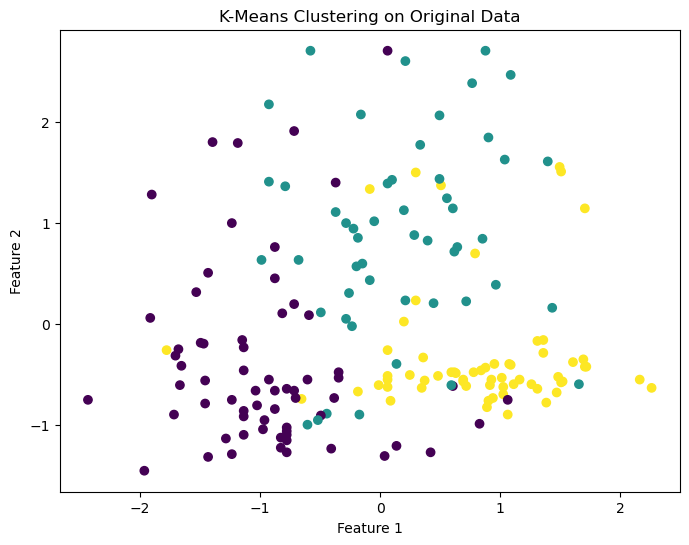

In [117]:
# Visualize the clustering results 
plt.figure(figsize=(8,6))
plt.scatter(features_scaled.iloc[:, 0],features_scaled.iloc[:, 1],c=clusters,cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering on Original Data")
plt.show()

In [118]:
from sklearn.metrics import silhouette_score
silhouette_original=silhouette_score(features_scaled,clusters)
silhouette_original

0.3207885469405263

#### elbow method

In [119]:
inertia=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)
print(inertia)

[2440.949438202247, 1742.5333806733365, 1266.070346209317, 1183.605938098931, 1133.9572114550153, 1049.391295171919, 1016.7261891190062, 987.0385172400272, 908.868192508239]


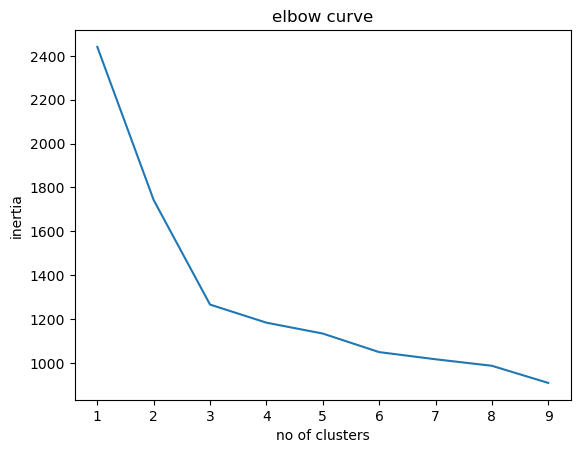

In [120]:
plt.plot(range(1,10),inertia)
plt.xlabel('no of clusters')
plt.ylabel('inertia')
plt.title('elbow curve')
plt.show()

### Task 4: Clustering with PCA Data:

In [121]:
kmeans1 = KMeans(n_clusters=3,random_state=42)

In [122]:
clusters1= kmeans1.fit_predict(pca_data)

In [123]:
pca_data['PC3'] = clusters1
pca_data

,PC1,PC2,PC3
0,3.358147,1.520222,2
1,2.229215,-0.333261,2
2,2.540057,1.036953,2
3,3.781124,2.782566,2
4,1.016872,0.955225,2
...,...,...,...
173,-3.311751,2.173369,1
174,-2.612425,1.797712,1
175,-2.671169,2.865301,1
176,-2.371603,2.393808,1


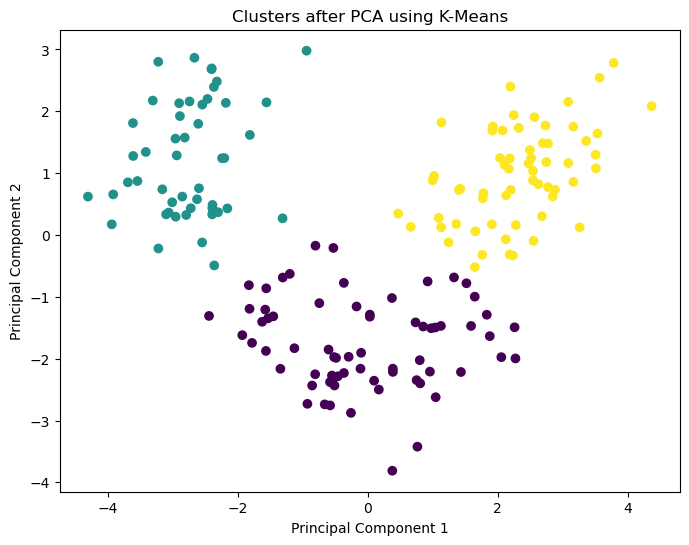

In [124]:
#Visualize the clustering results obtained from PCA-transformed data
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data['PC1'],
    pca_data['PC2'],
    c=clusters1,
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clusters after PCA using K-Means")

plt.show()

In [125]:
from sklearn.metrics import silhouette_score
silhouette_pca=silhouette_score(pca_data,clusters1)
silhouette_pca

0.6098998883407599

#### elbow method

In [126]:
inertia=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)
print(inertia)

[1426.5449807881405, 764.8592807777027, 262.8467307114774, 225.477264966101, 163.57653463772252, 126.08161502918449, 102.14738808800081, 94.68886931872204, 85.20516746065469]


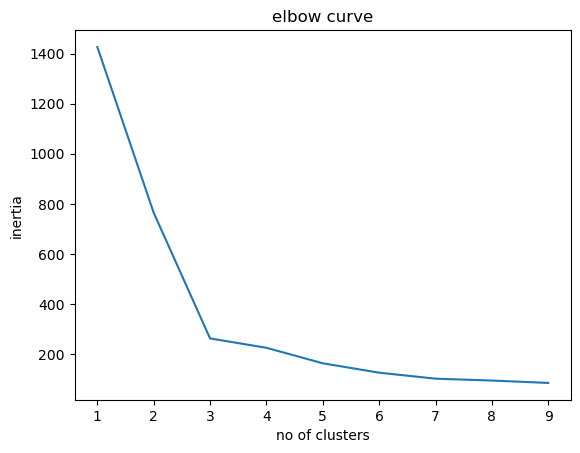

In [127]:
plt.plot(range(1,10),inertia)
plt.xlabel('no of clusters')
plt.ylabel('inertia')
plt.title('elbow curve')
plt.show()

### Task 5: Comparison and Analysis:

#### compare results

In [128]:
comparison = pd.DataFrame({
    'Method': ['Original Data', 'PCA Data'],
    
    'Silhouette Score':
    [silhouette_original, silhouette_pca],
})

print(comparison)

          Method  Silhouette Score
0  Original Data          0.320789
1       PCA Data          0.609900


#### Similarities and Differences:

##### Both methods created clusters from similar data points.
##### PCA data gave clearer and cleaner clusters.
##### Original data contained more detailed information and noise.

#### Impact of Dimensionality Reduction:

##### PCA reduced the number of features.
##### It improved clustering speed and visualization.
##### Removing noise helped improve cluster quality.

#### Trade-Offs:

##### Original data keeps all information but takes more computation.
##### PCA is faster but may lose some information.
##### PCA clusters are easier to visualize than original data clusters.

### Task 6: Conclusion and Insights

#### Key Findings and Insights:

##### PCA reduced the number of features while keeping important information.
##### K-Means clustering grouped similar data points successfully.
##### PCA-transformed data gave better visualization of clusters.
##### Clustering performance improved after reducing noise and redundant features.

#### Practical Implications:

##### PCA helps simplify complex datasets.
##### Clustering helps identify hidden patterns in the data.
##### PCA improves computation speed and visualization.
##### Combining PCA and clustering makes analysis more efficient.

#### Recommendations:

##### Use PCA for high-dimensional datasets with many features.
##### Use clustering to group similar records or observations.
##### Apply PCA before clustering for faster processing and cleaner clusters.
##### Use original data when complete feature interpretation is important.